# Coursework (DTS110TC)
## Task: Modeling Global Warming Trends for Sustainable Development



Welcome to the coursework for DTS110TC! In this task, you will leverage your analysis to explore global warming trends using temperature data—starting from foundational curve fitting, progressing to forecasting future temperatures, and extending to modeling extreme weather patterns.  

Upon completing the `coding` component, you are required to submit a comprehensive `report` that `addresses all questions` outlined in each section of the task. Beyond answering these questions, you should expand into discussions of **industry-related challenges** tied to global warming and sustainable development (e.g., climate data integration in energy planning, extreme weather resilience for manufacturing). `Crucially, propose your own solutions to these challenges`—this is your opportunity to connect insights from any module topics that resonate with you.  

This coursework is designed to bridge climate data analysis with industrial strategy design—ultimately creating space for you to `contribute your insights on data-driven sustainable development decisions`. 

## Overview 
 
In this task, you will:  
1. Fit polynomial models to temperature data and evaluate their accuracy.  
2. Reduce noise with moving averages and aggregate data across cities.  
3. Test how well historical data predicts future temperatures.  
4. Analyze whether global warming increases temperature extremality.
5. Discuss industry-specific challenges tied to global warming and sustainable

## Setup
First, import required libraries and load helper code. Ensure `data.csv` is in the same folder as this notebook.
#### ** TODO: ** `Run the cell below to get started.`

In [263]:
import pylab
import re
import math
import matplotlib.pyplot as plt
import unittest


# Magic command to display plots inline
%matplotlib inline

# List of cities in the dataset
CITIES = [
    'BOSTON', 'SEATTLE', 'SAN DIEGO', 'PHILADELPHIA', 'PHOENIX',
    'LAS VEGAS', 'CHARLOTTE', 'DALLAS', 'BALTIMORE', 'SAN JUAN',
    'LOS ANGELES', 'MIAMI', 'NEW ORLEANS', 'ALBUQUERQUE', 'PORTLAND',
    'SAN FRANCISCO', 'TAMPA', 'NEW YORK', 'DETROIT', 'ST LOUIS', 'CHICAGO'
]

# Time intervals for training (historical) and testing (future) data
TRAINING_INTERVAL = range(1961, 2010)
TESTING_INTERVAL = range(2010, 2016)

class Climate(object):
    """
    The collection of temperature records loaded from given csv file
    """
    def __init__(self, filename):
        """
        Initialize a Climate instance, which stores the temperature records
        loaded from a given csv file specified by filename.

        Args:
            filename: name of the csv file (str)
        """
        self.rawdata = {}

        f = open(filename, 'r')
        header = f.readline().strip().split(',')
        for line in f:
            items = line.strip().split(',')

            date = re.match(r'(\d\d\d\d)(\d\d)(\d\d)', items[header.index('DATE')])
            year = int(date.group(1))
            month = int(date.group(2))
            day = int(date.group(3))

            city = items[header.index('CITY')]
            temperature = float(items[header.index('TEMP')])
            if city not in self.rawdata:
                self.rawdata[city] = {}
            if year not in self.rawdata[city]:
                self.rawdata[city][year] = {}
            if month not in self.rawdata[city][year]:
                self.rawdata[city][year][month] = {}
            self.rawdata[city][year][month][day] = temperature
            
        f.close()

    def get_yearly_temp(self, city, year):
        """
        Get the daily temperatures for the given year and city.

        Args:
            city: city name (str)
            year: the year to get the data for (int)

        Returns:
            a 1-d pylab array of daily temperatures for the specified year and
            city
        """
        temperatures = []
        assert city in self.rawdata, "provided city is not available"
        assert year in self.rawdata[city], "provided year is not available"
        for month in range(1, 13):
            for day in range(1, 32):
                if day in self.rawdata[city][year][month]:
                    temperatures.append(self.rawdata[city][year][month][day])
        return pylab.array(temperatures)

    def get_daily_temp(self, city, month, day, year):
        """
        Get the daily temperature for the given city and time (year + date).

        Args:
            city: city name (str)
            month: the month to get the data for (int, where January = 1,
                December = 12)
            day: the day to get the data for (int, where 1st day of month = 1)
            year: the year to get the data for (int)

        Returns:
            a float of the daily temperature for the specified time (year +
            date) and city
        """
        assert city in self.rawdata, "provided city is not available"
        assert year in self.rawdata[city], "provided year is not available"
        assert month in self.rawdata[city][year], "provided month is not available"
        assert day in self.rawdata[city][year][month], "provided day is not available"
        return self.rawdata[city][year][month][day]

def se_over_slope(x, y, estimated, model):
    """
    For a linear regression model, calculate the ratio of the standard error of
    this fitted curve's slope to the slope. The larger the absolute value of
    this ratio is, the more likely we have the upward/downward trend in this
    fitted curve by chance.
    
    Args:
        x: an 1-d pylab array with length N, representing the x-coordinates of
            the N sample points
        y: an 1-d pylab array with length N, representing the y-coordinates of
            the N sample points
        estimated: an 1-d pylab array of values estimated by a linear
            regression model
        model: a pylab array storing the coefficients of a linear regression
            model

    Returns:
        a float for the ratio of standard error of slope to slope
    """
    assert len(y) == len(estimated)
    assert len(x) == len(estimated)
    EE = ((estimated - y)**2).sum()
    var_x = ((x - x.mean())** 2).sum()
    SE = pylab.sqrt(EE/(len(x)-2)/var_x)
    return SE/model[0]


## Part 1: Creating Models
In this section, you’ll implement core functions for regression modeling: fitting polynomials to data, evaluating model accuracy with \(R^2\), and visualizing results.

### 1.1 Curve Fitting
Implement `generate_models` to fit polynomial regression models to (x, y) data for specified degrees. Use `pylab.polyfit` (least-squares fitting) to get model coefficients.
#### ** TODO: ** `Complete the 'generate_models' function`.


In [201]:
def generate_models(x, y, degs):
    """
    Generate regression models by fitting a polynomial for each degree in degs
    to points (x, y).

    Args:
        x: an 1-d pylab array with length N, representing the x-coordinates of
            the N sample points
        y: an 1-d pylab array with length N, representing the y-coordinates of
            the N sample points
        degs: a list of degrees of the fitting polynomial

    Returns:
        a list of pylab arrays, where each array is a 1-d array of coefficients
        that minimizes the squared error of the fitting polynomial
    """
    # TODO
    models = []
    for deg in degs:
        model = pylab.polyfit(x, y, deg)
        models.append(model)
    return models

#### 1.1.1 Test Your Implementation
Run the cell below to verify `generate_models` works with the provided test cases.

#### ** TODO: ** `Run the cell below to test your implementation.`

In [204]:
# Test 1: Simple linear fit (y = x)
x = pylab.array(range(50))
y = pylab.array(range(50))
models = generate_models(x, y, [1])
assert len(models) == 1, "Should return 1 model for 1 degree"
assert list(models[0]) == list(pylab.polyfit(x, y, 1)), "Linear coefficients mismatch"

# Test 2: Multiple degrees (linear and quadratic for y = 2x)
y = pylab.array(range(0, 100, 2))
models = generate_models(x, y, [1, 2])
assert len(models) == 2, "Should return 2 models for 2 degrees"
assert list(models[0]) == list(pylab.polyfit(x, y, 1)), "Linear coefficients mismatch"
assert list(models[1]) == list(pylab.polyfit(x, y, 2)), "Quadratic coefficients mismatch"

print("All generate_models tests passed!")

All generate_models tests passed!


### 1.2 Evaluate Model Fit with (R^2)
<!-- Use proper LaTeX notation for mathematical expressions -->
The $R^2$ metric measures how well a model explains variation in the data (range: $-\infty$ to 1). A value of 1 means perfect fit; values ≤ 0 mean the model is worse than predicting the mean.

Implement `r_squared` using the formula:  
<!-- The R-squared formula calculates the proportion of variance explained by the model -->
<!-- The numerator represents the sum of squared residuals (prediction errors) -->
<!-- The denominator represents the total sum of squares (total variance in the data) -->
$$ R^2 = 1 - \frac{\sum_{i=1}^n (y_i - \hat{y}_i)^2}{\sum_{i=1}^n (y_i - \bar{y})^2} $$  
Where:  
- $y_i$ = actual temperature,  
- $\hat{y}_i$ = model-predicted temperature,  
- $\bar{y}$ = mean of actual temperatures.

#### ** TODO: ** `Complete the 'r_squared' function`.

In [266]:
def r_squared(y, estimated):
    """
    Calculate the R-squared error term.
    
    Args:
        y: 1-d pylab array with length N, representing the y-coordinates of the
            N sample points
        estimated: an 1-d pylab array of values estimated by the regression
            model

    Returns:
        a float for the R-squared error term
    """
    # TODO
    mean_y = pylab.mean(y)
    numerator = ((y - estimated) ** 2).sum()
    denominator = ((y - mean_y) ** 2).sum()
    return 1 - (numerator / denominator)

#### 1.2.1 Test Your Implementation
Run the cell below to validate your \(R^2\) calculation.

#### ** TODO: ** `Run the cell below to test your implementation.`

In [269]:
# Test 1: Perfect fit (R² = 1)
y = pylab.array([0, 1, 2, 3, 4])
estimated = pylab.array([0, 1, 2, 3, 4])
assert r_squared(y, estimated) == 1.0, "Perfect fit should return R² = 1"

# Test 2: Poor fit (R² ≈ -0.03)
y = pylab.array(range(10))
estimated = pylab.array([5]*10)
assert round(r_squared(y, estimated), 6) == -0.030303, "Poor fit R² mismatch"

# Test 3: Worse fit (R² ≈ -2.45)
estimated = pylab.array(range(0, 20, 2))
assert round(r_squared(y, estimated), 6) == -2.454545, "Worse fit R² mismatch"

print("All r_squared tests passed!")

All r_squared tests passed!


### 1.3 Visualize Models
Implement `evaluate_models_on_training` to plot raw data and model fits, then label plots with key metrics (R^2), and standard error-to-slope ratio for linear models).

#### ** TODO: ** `Complete the 'evaluate_models_on_training' function`.

In [282]:
def evaluate_models_on_training(x, y, models):
    """
    For each regression model, compute the R-squared value for this model with the
    standard error over slope of a linear regression line (only if the model is
    linear), and plot the data along with the best fit curve.

    For the plots, you should plot data points (x,y) as blue dots and your best
    fit curve (aka model) as a red solid line. You should also label the axes
    of this figure appropriately and have a title reporting the following
    information:
        degree of your regression model,
        R-square of your model evaluated on the given data points,
        and SE/slope (if degree of this model is 1 -- see se_over_slope). 

    Args:
        x: an 1-d pylab array with length N, representing the x-coordinates of
            the N sample points
        y: an 1-d pylab array with length N, representing the y-coordinates of
            the N sample points
        models: a list containing the regression models you want to apply to
            your data. Each model is a pylab array storing the coefficients of
            a polynomial.

    Returns:
        None
    """
    # TODO
    for model in models:
         pylab.figure()
         pylab.plot(x, y, 'b.', label='Data')
         estimated = pylab.polyval(model, x)
         pylab.plot(x, estimated, 'r-', label='Model')
         r2 = r_squared(y, estimated)
         degree = len(model) - 1
         title_str = f'Degree: {degree}, R2: {r2:.4f}'
         if degree == 1:
             ratio = se_over_slope(x, y, estimated, model)
             title_str += f', SE/slope: {ratio:.4f}'

         pylab.title(title_str)
         pylab.xlabel('Year')
         pylab.ylabel('Temperature (Celsius)')
         pylab.legend(loc='best')
         pylab.show()

### 1.4 Investigate Temperature Trends
Use the `Climate` class and your model functions to analyze two temperature metrics for New York City (1961–2009):  
- **1.4.1**: Temperature on January 10th (specific day).  
- **1.4.2**: Average annual temperature (reduces daily noise).  

#### 1.4.1 January 10th Temperatures (NYC)
First, extract January 10th temperatures for NYC from 1961–2009, then fit a linear model and visualize.

#### ** TODO: ** `Run the cell below.`

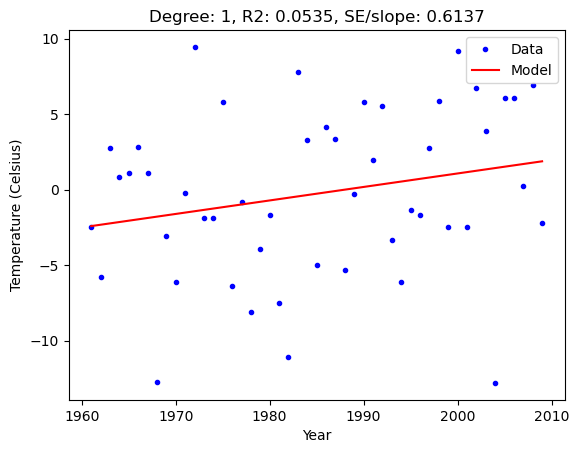

In [285]:
# Step 1: Load climate data and extract January 10th temperatures
climate = Climate('data.csv')
city = 'NEW YORK'
years = pylab.array(TRAINING_INTERVAL)
jan10_temps = []

for year in years:
    # Get temperature for January 10th (month=1, day=10)
    temp = climate.get_daily_temp(city, month=1, day=10, year=year)
    jan10_temps.append(temp)
jan10_temps = pylab.array(jan10_temps)

# Step 2: Fit linear model (degree=1)
models_jan10 = generate_models(years, jan10_temps, [1])

# Step 3: Visualize and evaluate
evaluate_models_on_training(years, jan10_temps, models_jan10)

#### 1.4.2 Average Annual Temperatures (NYC)
Next, calculate NYC’s average annual temperature for 1961–2009 (accounting for leap years), then fit a linear model.
#### ** TODO: ** `Run the cell below.`


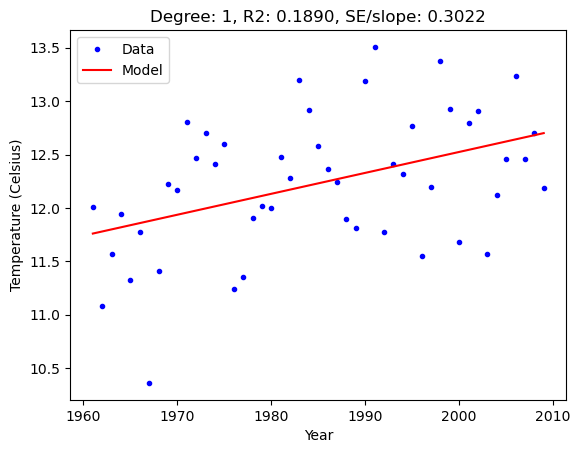

In [288]:
# Step 1: Calculate average annual temperature for each year
annual_avg_temps = []
for year in years:
    # Get daily temperatures for the year, then compute mean
    daily_temps = climate.get_yearly_temp(city, year)
    annual_avg = daily_temps.mean()
    annual_avg_temps.append(annual_avg)
annual_avg_temps = pylab.array(annual_avg_temps)

# Step 2: Fit linear model (degree=1)
models_annual = generate_models(years, annual_avg_temps, [1])

# Step 3: Visualize and evaluate
evaluate_models_on_training(years, annual_avg_temps, models_annual)

#### 1.4.3 `Analysis Questions` (** TODO: **`Add to Your Report`)
1. How do the \(R^2\) values and curve fits differ between January 10th temperatures and annual averages?  
2. Why is one dataset noisier than the other?  
3. Do these plots support global warming (rising temperatures)? Use the slope and SE/slope ratio to justify your answer.  

## Part 2: Incorporating More Data
Aggregate temperature data across all 21 U.S. cities to reduce noise and get a national trend.

### 2.1 Aggregate City Averages 
Implement `gen_cities_avg` to compute the **national average temperature** for each year (average of annual averages across cities).

### ** TODO: ** `Complete the 'gen_cities_avg' function`.

In [380]:
def gen_cities_avg(climate, multi_cities, years):
    """
    Compute the average annual temperature over multiple cities.

    Args:
        climate: instance of Climate
        multi_cities: the names of cities we want to average over (list of str)
        years: the range of years of the yearly averaged temperature (list of
            int)

    Returns:
        a pylab 1-d array of floats with length = len(years). Each element in
        this array corresponds to the average annual temperature over the given
        cities for a given year.
    """
    # TODO
    national_avgs = []
    for year in years:
        city_means_for_year = []
        for city in multi_cities:
            daily_temps = climate.get_yearly_temp(city, year)
            city_mean = daily_temps.mean()
            city_means_for_year.append(city_mean)

        national_avgs.append(pylab.array(city_means_for_year).mean())
    return pylab.array(national_avgs)

#### 2.1.1 Test Your Implementation
Run the cell below to verify the aggregation works.
#### ** TODO: ** `Run the cell below to test your implementation.`


In [383]:
# Test 1: Single city (Seattle, testing interval 2010–2015)
test_years = pylab.array(TESTING_INTERVAL)
seattle_avg = gen_cities_avg(climate, ['SEATTLE'], test_years)
correct_seattle = [11.514, 10.587, 11.283, 12.106, 12.829, 13.132]
assert all(math.isclose(seattle_avg[i], correct_seattle[i], rel_tol=0.01) 
           for i in range(len(seattle_avg))), "Single-city average mismatch"

# Test 2: Multiple cities (all 21 cities, testing interval)
national_avg = gen_cities_avg(climate, CITIES, test_years)
correct_national = [16.760, 16.857, 17.562, 16.657, 16.845, 17.545]
assert all(math.isclose(national_avg[i], correct_national[i], rel_tol=0.01) 
           for i in range(len(national_avg))), "Multi-city average mismatch"

print("All gen_cities_avg tests passed!")

All gen_cities_avg tests passed!


#### 2.1.2 Visualize National Temperature Trend
Fit a linear model to the national average temperatures (1961–2009) and plot the results.

#### ** TODO: ** `Run the cell below.`

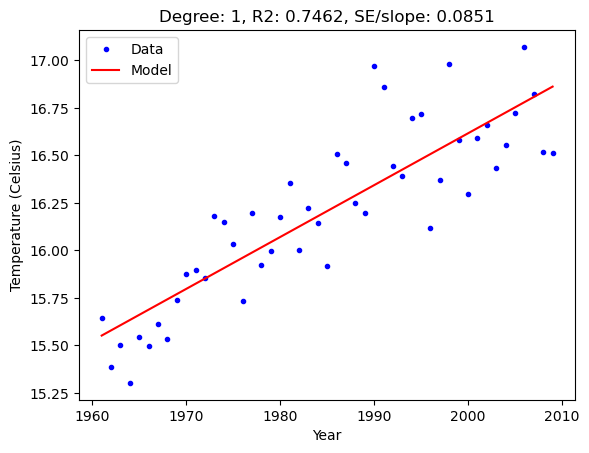

In [386]:
# Step 1: Compute national average temperatures (1961–2009)
national_temps = gen_cities_avg(climate, CITIES, TRAINING_INTERVAL)
years = pylab.array(TRAINING_INTERVAL)

# Step 2: Fit linear model
models_national = generate_models(years, national_temps, [1])

# Step 3: Visualize
evaluate_models_on_training(years, national_temps, models_national)

#### 2.1.3 `Analysis Questions` (** TODO: **`Add to Your Report`)
1. How does the national trend compare to NYC’s single-city trends (Part 1)? Focus on \(R^2\) and trend clarity.  
2. Why does aggregating across cities improve the model?  


## Part 3: 5-Year Moving Average
Moving averages smooth out short-term noise to highlight long-term trends. Implement a function to compute moving averages, then apply it to national temperatures.

### 3.1 Moving Average
Implement `moving_average` to compute a sliding-window average of a dataset. For the first `window_length-1` points, average over all available prior data (e.g., window=3: 1st point = [1], 2nd = [1,2], 3rd = [1,2,3]).

### ** TODO: ** `Complete the 'moving_average' function`.

In [389]:
def moving_average(y, window_length):
    """
    Compute the moving average of y with specified window length.

    Args:
        y: an 1-d pylab array with length N, representing the y-coordinates of
            the N sample points
        window_length: an integer indicating the window length for computing
            moving average

    Returns:
        an 1-d pylab array with the same length as y storing moving average of
        y-coordinates of the N sample points
    """
    # TODO
    averaged_y = []
    for i in range(len(y)):
        start_idx = max(0, i - window_length + 1)
        window_mean = pylab.mean(y[start_idx : i + 1])
        averaged_y.append(window_mean)

    return pylab.array(averaged_y)

#### 3.1.1 Test Your Implementation
Run the cell below to validate the moving average calculation.

#### ** TODO: ** `Run the cell below to test your implementation.`

In [392]:
# Test 1: Simple window=3 case
y = pylab.array([1, 2, 3, 4, 5, 6, 7])
window = 3
correct = pylab.array([1, 1.5, 2, 3, 4, 5, 6])
result = moving_average(y, window)
assert list(result) == list(correct), "Moving average mismatch (Test 1)"

# Test 2: Window=2 with negative values
y = pylab.array([-1.5, 1.5, -3.0, 3.0, -4.5, 4.5])
window = 2
correct = pylab.array([-1.5, 0, -0.75, 0, -0.75, 0])
result = moving_average(y, window)
assert list(result) == list(correct), "Moving average mismatch (Test 2)"

print("All moving_average tests passed!")

All moving_average tests passed!


#### 3.1.2 Visualize Smoothed National Trend
Apply a 5-year moving average to the national temperatures (1961–2009), then fit a linear model and plot.
#### ** TODO: ** `Run the cell below.`


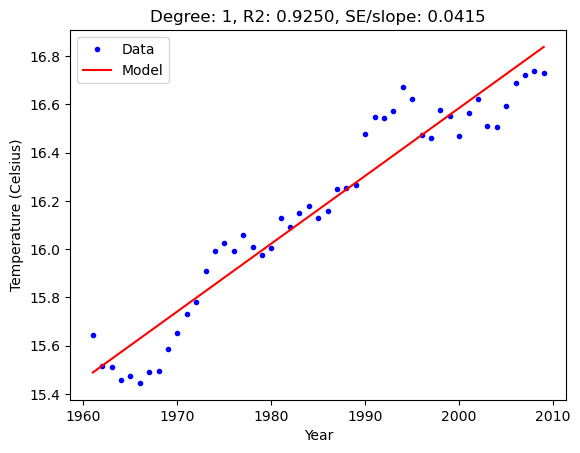

In [395]:
# Step 1: Compute 5-year moving average of national temperatures
window_length = 5
national_ma = moving_average(national_temps, window_length)

# Step 2: Fit linear model to smoothed data
models_ma = generate_models(years, national_ma, [1])

# Step 3: Visualize
evaluate_models_on_training(years, national_ma, models_ma)

#### 3.1.3 `Analysis Questions` (** TODO: **`Add to Your Report`)
1. How does the moving average trend compare to the raw national trend? Focus on \(R^2\) and noise.  
2. Why does the moving average make the trend clearer?  

## Part 4: Predicting the Future
Use historical data (1961–2009) to train models, then test their ability to predict 2010–2015 temperatures. You’ll use **RMSE** (Root Mean Square Error) to evaluate prediction accuracy.

### 4.1 Evaluate Predictions with RMSE
RMSE measures the average magnitude of prediction errors (lower = better). Implement `rmse` and `evaluate_models_on_testing` (plots test data + predictions with RMSE).

#### 4.1.1 RMSE Calculation (`rmse`)
Implement `rmse` using the formula:  
<!-- The RMSE formula calculates the square root of the average squared prediction error -->
$$ RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2} $$  
Where $n$ = number of data points.

### ** TODO: ** `Complete the 'rmse' function`.

In [398]:
def rmse(y, estimated):
    """
    Calculate the root mean square error term.

    Args:
        y: an 1-d pylab array with length N, representing the y-coordinates of
            the N sample points
        estimated: an 1-d pylab array of values estimated by the regression
            model

    Returns:
        a float for the root mean square error term
    """
    # TODO
    error = ((y - estimated) ** 2).sum()
    rmse_val = pylab.sqrt(error / len(y))
    return rmse_val

#### 4.1.2 Visualize Test Predictions 
Implement `evaluate_models_on_testing` to plot test data, model predictions, and RMSE.
### ** TODO: ** `Complete the 'evaluate_models_on_testing' function`.

In [401]:
def evaluate_models_on_testing(x, y, models):
    """
    For each regression model, compute the RMSE for this model and plot the
    test data along with the model’s estimation.

    For the plots, you should plot data points (x,y) as blue dots and your best
    fit curve (aka model) as a red solid line. You should also label the axes
    of this figure appropriately and have a title reporting the following
    information:
        degree of your regression model,
        RMSE of your model evaluated on the given data points. 

    Args:
        x: an 1-d pylab array with length N, representing the x-coordinates of
            the N sample points
        y: an 1-d pylab array with length N, representing the y-coordinates of
            the N sample points
        models: a list containing the regression models you want to apply to
            your data. Each model is a pylab array storing the coefficients of
            a polynomial.

    Returns:
        None
    """
    # TODO
    for model in models:
        pylab.figure()
        pylab.plot(x, y, 'b.', label='Test Data')
        estimated = pylab.polyval(model, x)
        pylab.plot(x, estimated, 'r-', label='Prediction')
        error = rmse(y, estimated)
        degree = len(model) - 1

        pylab.title(f'Degree: {degree}, RMSE: {error:.4f}')
        pylab.xlabel('Year')
        pylab.ylabel('Temperature (Celsius)')
        pylab.legend()
        pylab.show()

#### 4.1.3 Test Your Implementation
Run the cell below to validate RMSE.
#### ** TODO: ** `Run the cell below to test your implementation.`


In [404]:
# Test 1: Large prediction errors
y = pylab.array([1, 2, 3, 4, 5, 6, 7, 8, 9])
estimated = pylab.array([1, 4, 9, 16, 25, 36, 49, 64, 81])
correct_rmse = 35.8515
assert math.isclose(rmse(y, estimated), correct_rmse, rel_tol=0.001), "RMSE mismatch (Test 1)"

# Test 2: All actual values = 1
y = pylab.array([1]*9)
correct_rmse = 40.5134
assert math.isclose(rmse(y, estimated), correct_rmse, rel_tol=0.001), "RMSE mismatch (Test 2)"

print("All rmse tests passed!")

All rmse tests passed!


### 4.2 Predict 2010–2015 Temperatures
Train models on **smoothed national data** (5-year moving average, 1961–2009) for degrees 1, 2, and 20. Then test their ability to predict 2010–2015 temperatures.

#### 4.2.1 Train Models on Smoothed Training Data
First, train degree 1, 2, and 20 models on the 5-year moving average of national training data.
#### ** TODO: ** `Run the cell below.`


C:\Users\14895\AppData\Local\Temp\ipykernel_2224\1116295055.py:20: RankWarning: Polyfit may be poorly conditioned
  model = pylab.polyfit(x, y, deg)


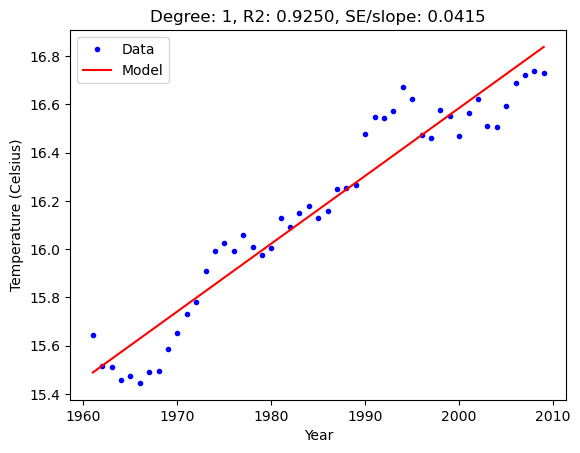

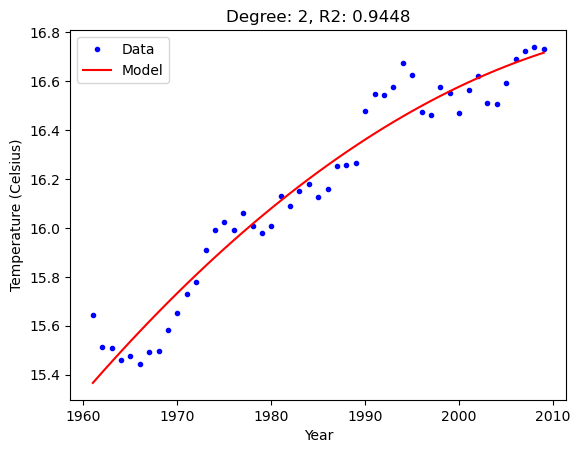

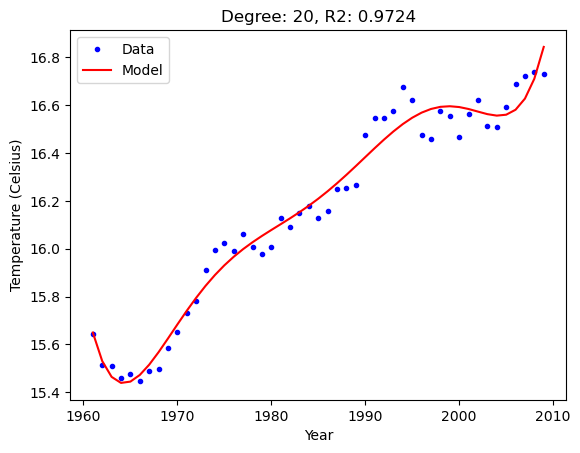

In [407]:
# Step 1: Get smoothed training data (from 3)
training_years = pylab.array(TRAINING_INTERVAL)
training_ma = national_ma  # 5-year MA of 1961–2009 national temps

# Step 2: Train models for degrees 1, 2, 20
models_pred = generate_models(training_years, training_ma, [1, 2, 20])

# Step 3: Visualize fits on training data
evaluate_models_on_training(training_years, training_ma, models_pred)

#### 4.2.2 Test Predictions on 2010–2015 Data
Next, compute the 5-year moving average of 2010–2015 national temperatures (test data), then use your trained models to predict these values and evaluate with RMSE.

#### ** TODO: ** `Run the cell below.`

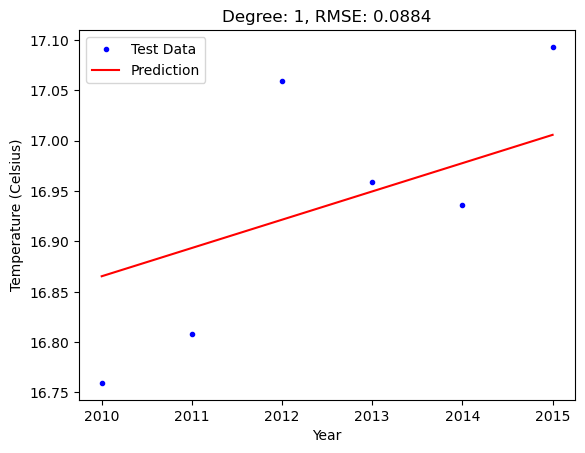

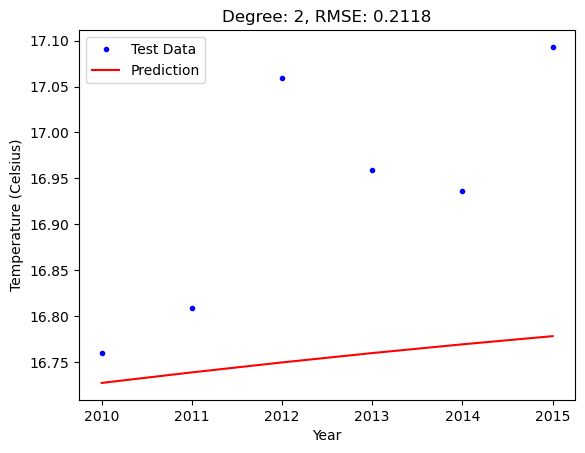

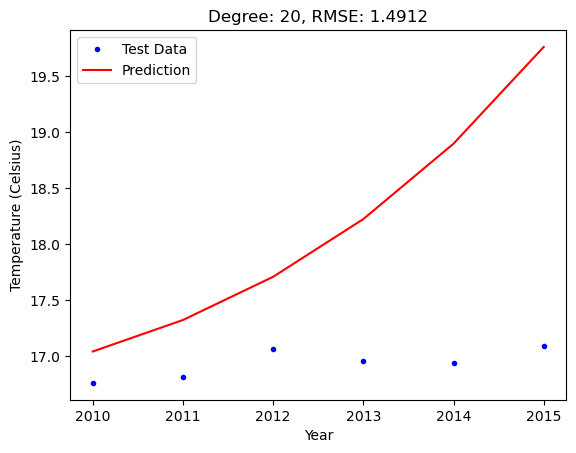

In [410]:
# Step 1: Compute 2010–2015 national temperatures (test data)
test_years = pylab.array(TESTING_INTERVAL)
test_national = gen_cities_avg(climate, CITIES, test_years)

# Step 2: Compute 5-year moving average of test data
test_ma = moving_average(test_national, window_length=5)

# Step 3: Evaluate models on test data
evaluate_models_on_testing(test_years, test_ma, models_pred)

#### 4.2.3 `Analysis Questions` (** TODO: **`Add to Your Report`)
1. Which model had the highest \(R^2\) on training data? Why?  
2. Which model performed best on test data (lowest RMSE)? Which performed worst?  
3. Why do the best training and test models differ?  


## Part 5: Modeling Extreme Temperatures
Global warming may increase temperature extremality (more hot/cold days). We test this by analyzing the **standard deviation** of daily temperatures (higher = more variation).

### 5.1 Compute Temperature Variability 
Implement `gen_std_devs` to calculate, for each year:  
1. Average temperature for each day across cities.  
2. Standard deviation of these daily averages (measures annual temperature variation).

### ** TODO: ** `Complete the 'gen_std_devs' function`.

In [413]:
def gen_std_devs(climate, multi_cities, years):
    """
    For each year in years, compute the standard deviation over the averaged yearly
    temperatures for each city in multi_cities. 

    Args:
        climate: instance of Climate
        multi_cities: the names of cities we want to use in our std dev calculation (list of str)
        years: the range of years to calculate standard deviation for (list of int)

    Returns:
        a pylab 1-d array of floats with length = len(years). Each element in
        this array corresponds to the standard deviation of the average annual 
        city temperatures for the given cities in a given year.
    """
    # TODO
    annual_std_devs = []
    for year in years:
        test_city = multi_cities[0]
        daily_national_avgs = []
        for month in range(1, 13):
            for day in range(1, 32):
                try:
                    temps_on_this_day = []
                    for city in multi_cities:
                        temp = climate.get_daily_temp(city, month, day, year)
                        temps_on_this_day.append(temp)

                    daily_national_avgs.append(pylab.mean(temps_on_this_day))
                except:
                    continue

        std_dev = pylab.std(daily_national_avgs)
        annual_std_devs.append(std_dev)
    return pylab.array(annual_std_devs)

#### 5.1.1 Test Your Implementation
Run the cell below to validate the standard deviation calculation.

#### ** TODO: ** `Run the cell below to test your implementation.`

In [416]:
# Test: Single city (Seattle, training interval 1961–2009)
seattle_std = gen_std_devs(climate, ['SEATTLE'], TRAINING_INTERVAL)
correct_first = 6.1119  # Expected std for 1961
correct_last = 6.5696   # Expected std for 2009
assert math.isclose(seattle_std[0], correct_first, rel_tol=0.01), "Std dev mismatch (1961)"
assert math.isclose(seattle_std[-1], correct_last, rel_tol=0.01), "Std dev mismatch (2009)"

print("gen_std_devs test passed!")

gen_std_devs test passed!


#### 5.1.2 Visualize Extremality Trend
Compute the 5-year moving average of annual standard deviations (1961–2009), then fit a linear model to test if variation is increasing.
#### ** TODO: ** `Run the cell below.`


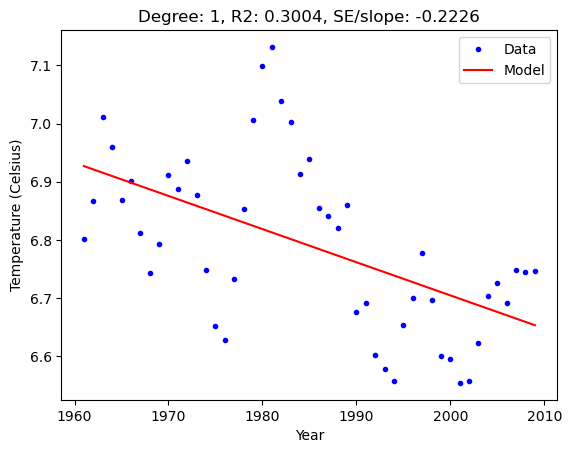

In [419]:
# Step 1: Compute annual standard deviations (all 21 cities, 1961–2009)
annual_std = gen_std_devs(climate, CITIES, TRAINING_INTERVAL)
years = pylab.array(TRAINING_INTERVAL)

# Step 2: Smooth with 5-year moving average
std_ma = moving_average(annual_std, window_length=5)

# Step 3: Fit linear model and visualize
models_std = generate_models(years, std_ma, [1])
evaluate_models_on_training(years, std_ma, models_std)

#### 5.1.3 `Analysis Questions` (** TODO: **`Add to Your Report`)
1. Does the trend show increasing temperature variation (supporting the extremality claim)? Use the slope and \(R^2\) to justify.  
2. What improvements could make this analysis more robust?

## Part 6: `Write-Up and Analytical Discussion`
#### ** TODO: ** `Propose Solutions in Your Report`

Propose solutions to challenges tied to the task theme, explicitly linking insights from relevant module topics, and contribute your insights on data-driven sustainable development decisions. 

In this section, discuss industry-specific challenges tied to global warming and sustainable development. The goal of this discussion is to bridge climate data analysis with industrial strategy design: use your findings from module topics that resonate with you to contribute meaningful insights on how AI-centric data-driven decisions can advance sustainable development in real-world industries.

Topics to Explore: 

6.1 Integrating Climate Data into Long-Term Energy Planning 

Leverage module insights (e.g., temperature trend forecasting, extreme weather pattern analysis via AI models) to propose how energy sectors can embed climate data into long-term planning. 

6.2 Enhancing Extreme Weather Resilience in Manufacturing

Draw on module concepts (e.g., analyzing temperature extremality via AI models for out-of-sample prediction) to design strategies for manufacturing sectors to adapt to climate-driven disruptions. 

6.3 Balancing Industrial Growth with Carbon Reduction Goals 

Connect module learnings (e.g., using aggregated multi-city data to measure climate impact, cross-validating models to ensure reliable carbon footprint predictions) to address the tension between industrial expansion and net-zero targets. 

6.4 Original Data-Driven Solutions 

Propose a unique, actionable solution to a global warming or sustainable development challenge not covered above. Your solution should:  
- Target a specific industry (e.g., agriculture, transportation, urban planning).  
- Draw on at least one technical concept from the module.  
- Be AI-centric, data-driven.
